In [1]:
import itertools

from scipy.stats import alpha
%matplotlib inline

import numpy as np
from pathlib import Path
from itertools import product
import os
import json
import matplotlib.pyplot as plt

In [2]:
data_dir = Path(os.getenv("OODIR"))
icoads_dir = data_dir / "ICOADS" / "OutputData"

In [3]:
n_time = (2025-1850+1)*12
all_decks = np.full((n_time, 1000), np.nan)
all_decks_unc = np.full((n_time, 1000), np.nan)

deck_list = []

last_year = 1850

for year, month in itertools.product(range(1850, 2025), range(1,13)):
    filename = icoads_dir / f"decks_{year}{month:02d}.json"
    if not filename.exists():
        continue

    last_year = year

    with open(filename) as f:
        deck_dict = json.load(f)

    tindex = (year-1850)*12 + month - 1

    del deck_dict["year"]
    del deck_dict["month"]

    for key, val in deck_dict.items():
        deck_list.append(int(key))
        all_decks[tindex, int(key)] = val[0]
        all_decks_unc[tindex, int(key)] = val[1]

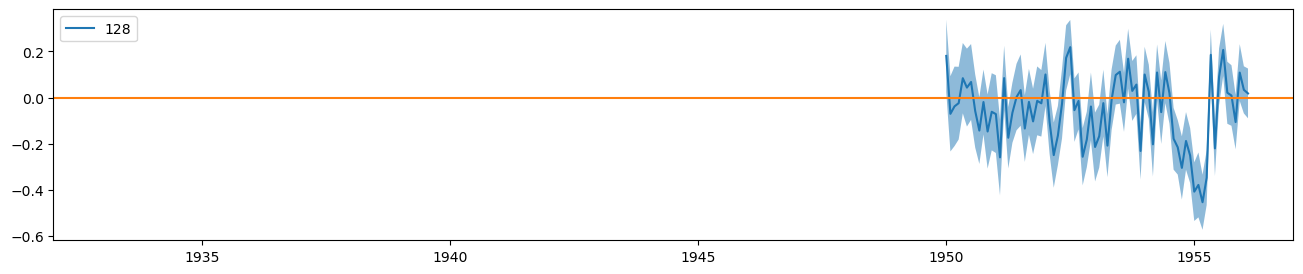

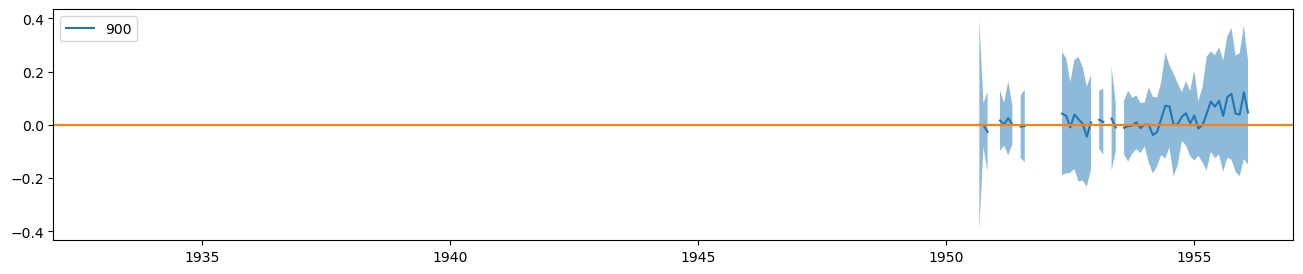

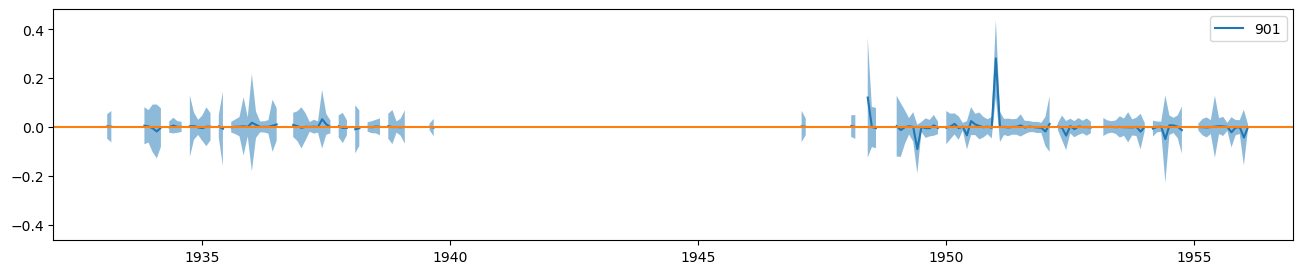

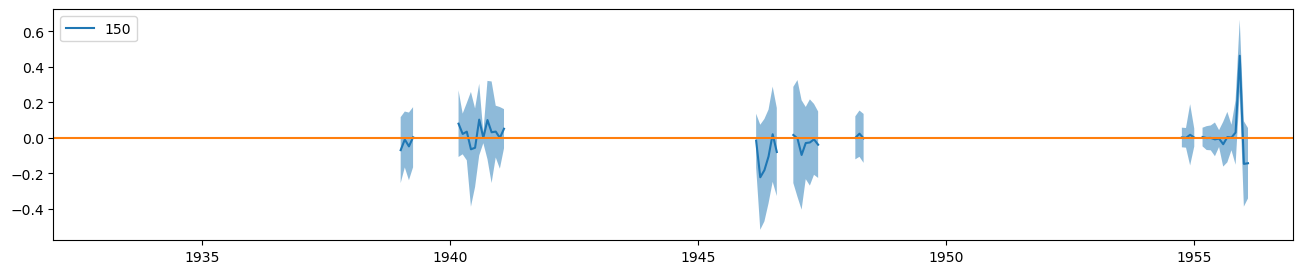

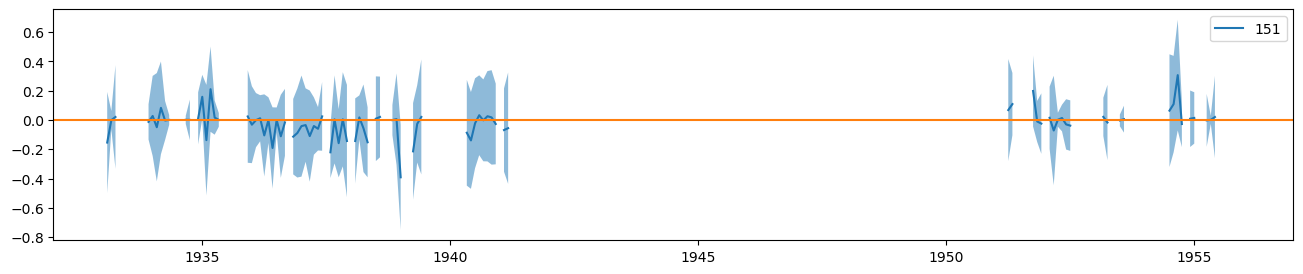

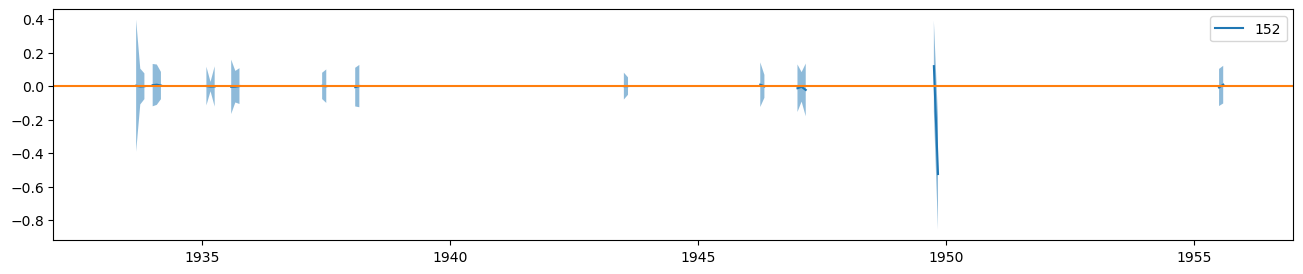

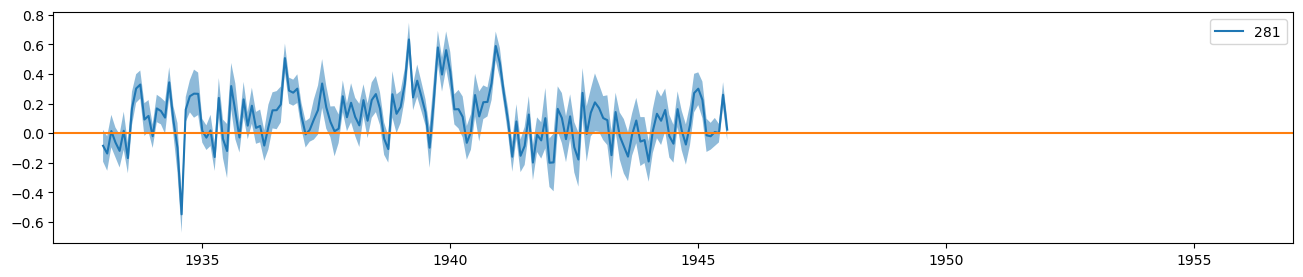

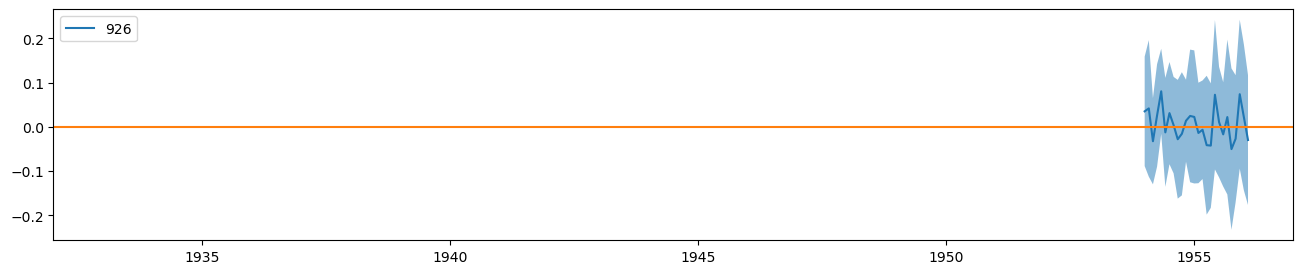

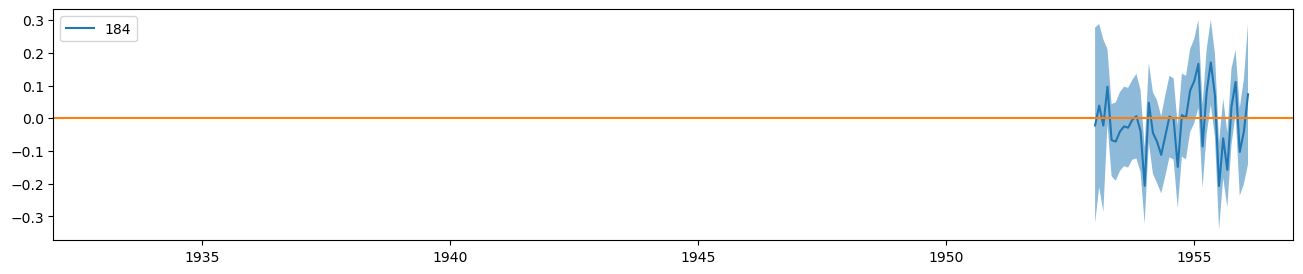

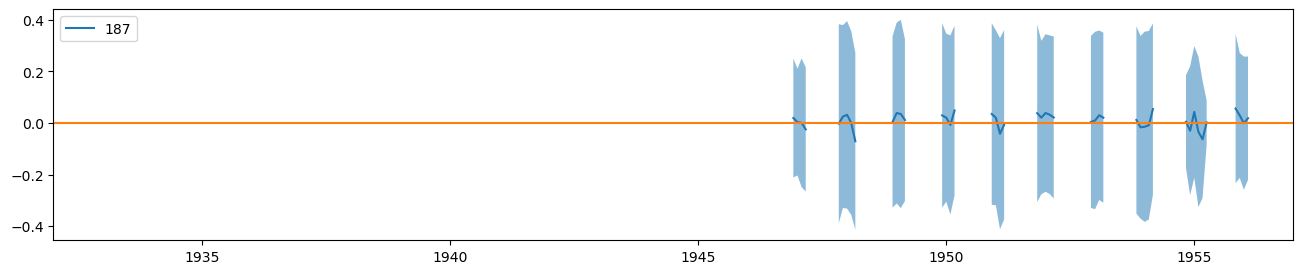

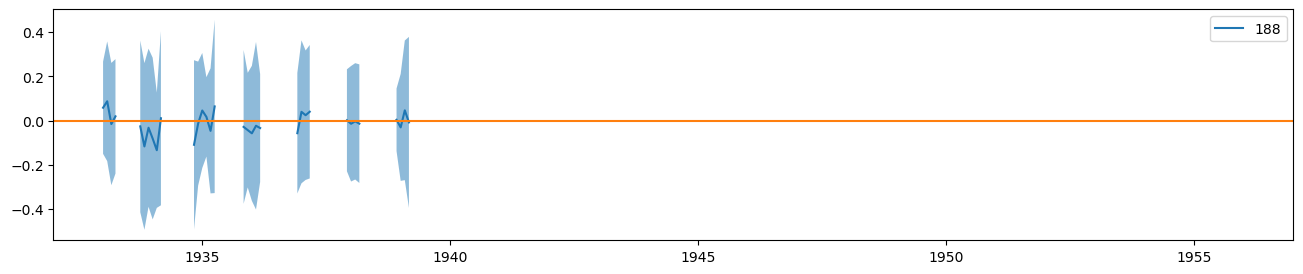

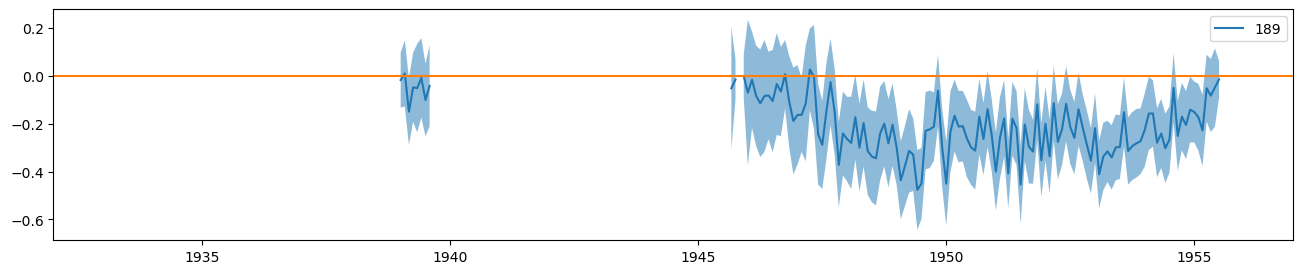

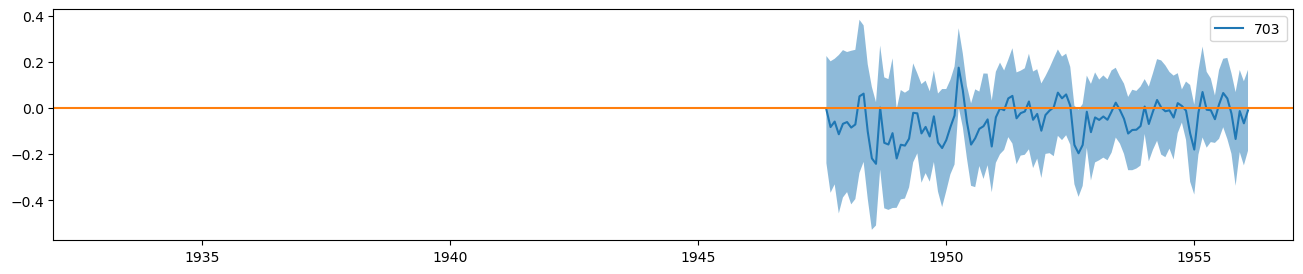

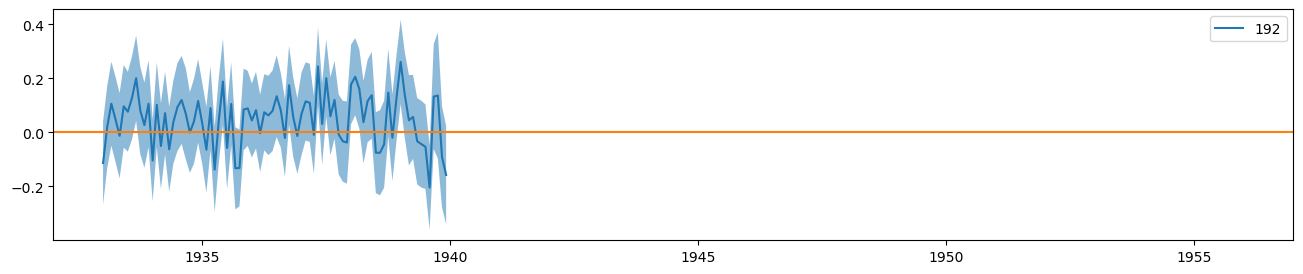

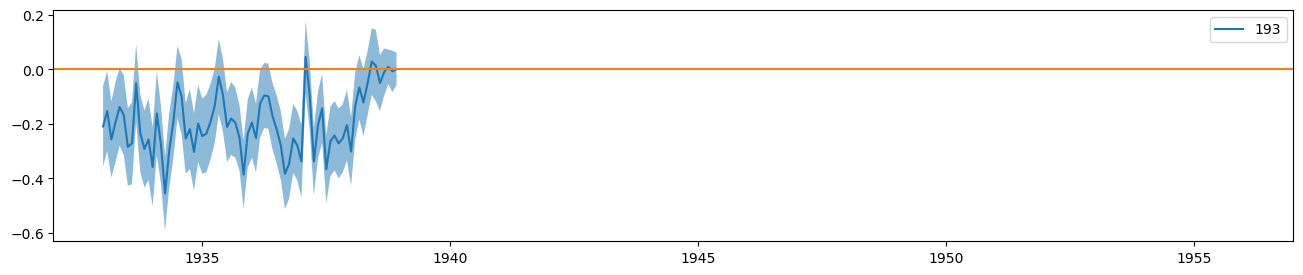

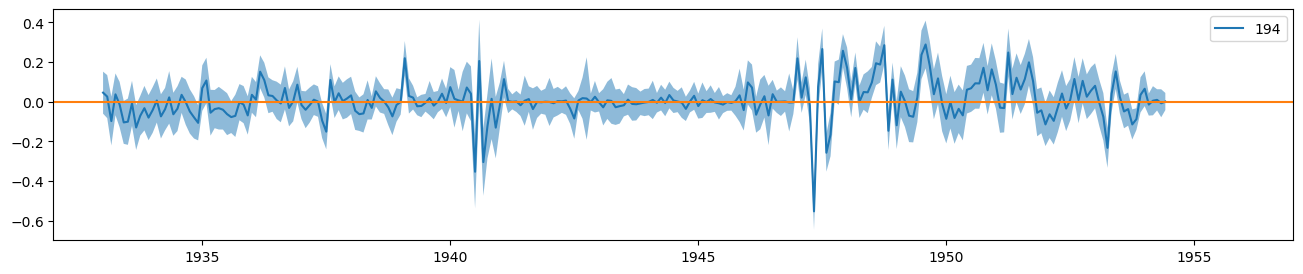

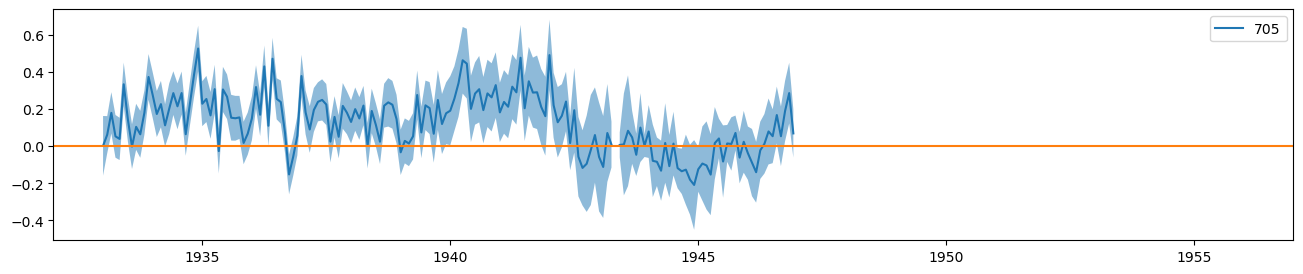

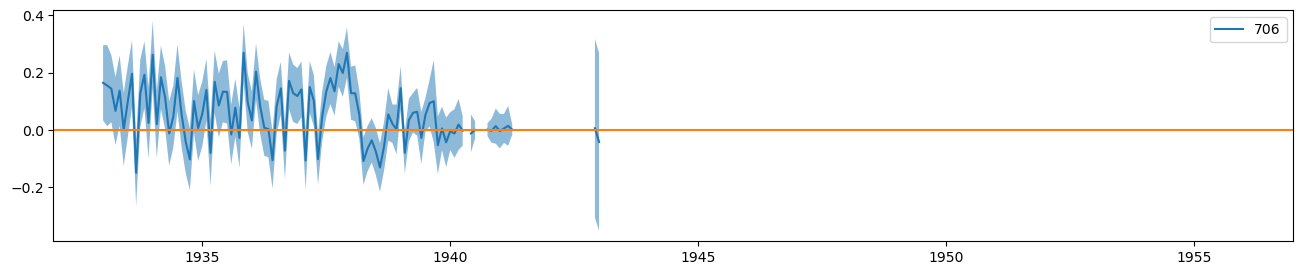

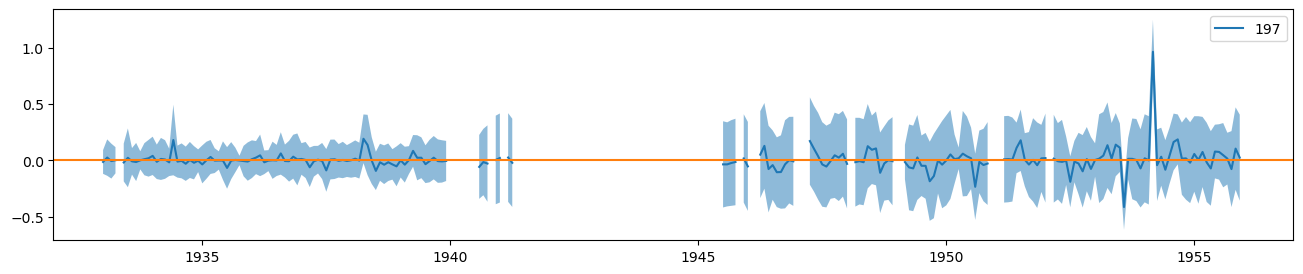

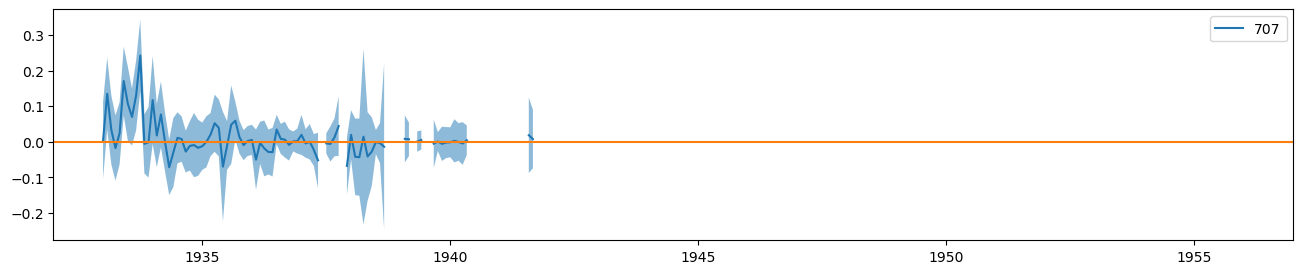

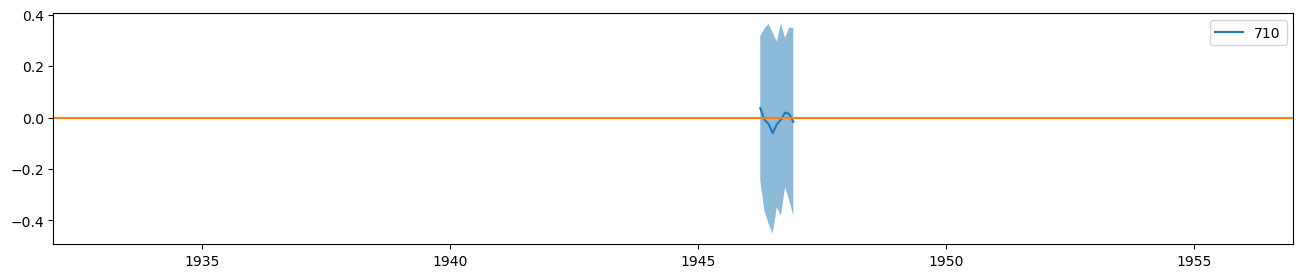

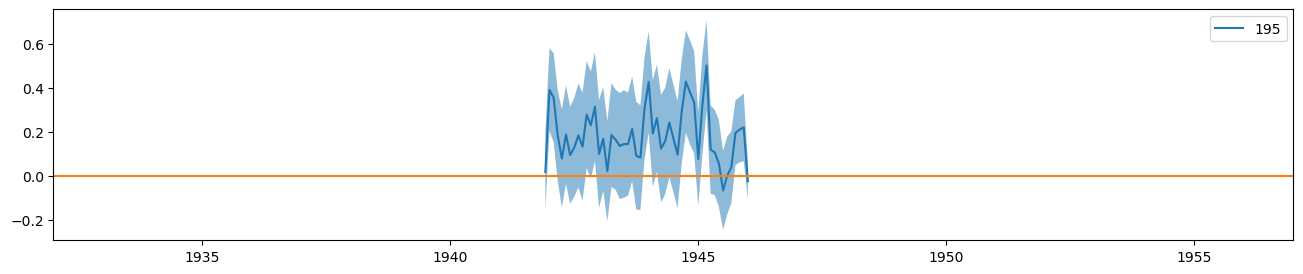

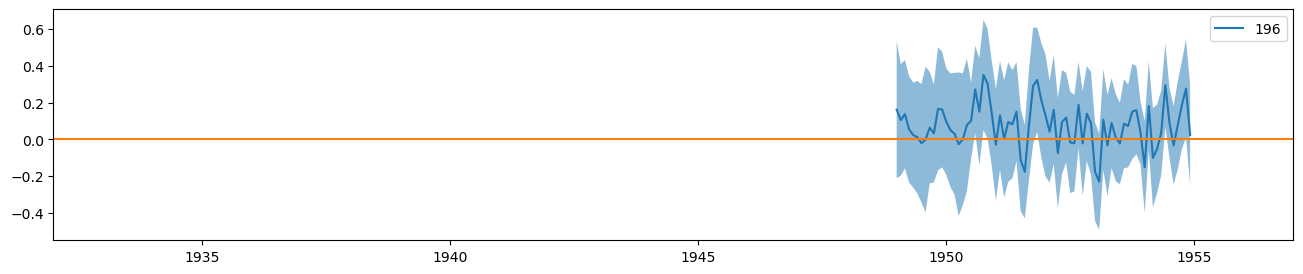

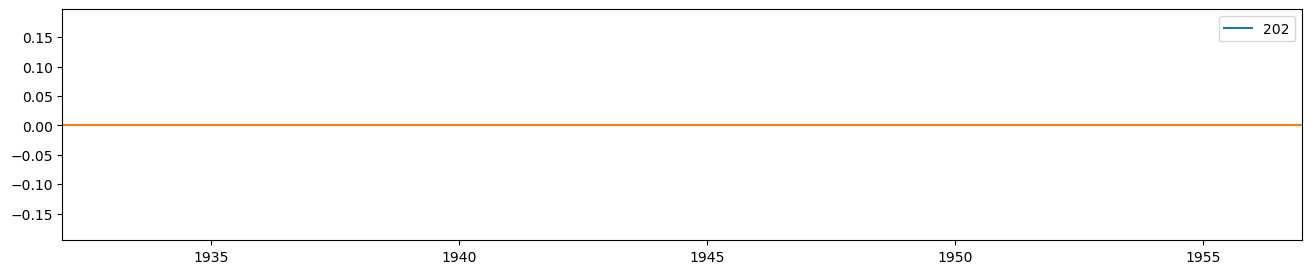

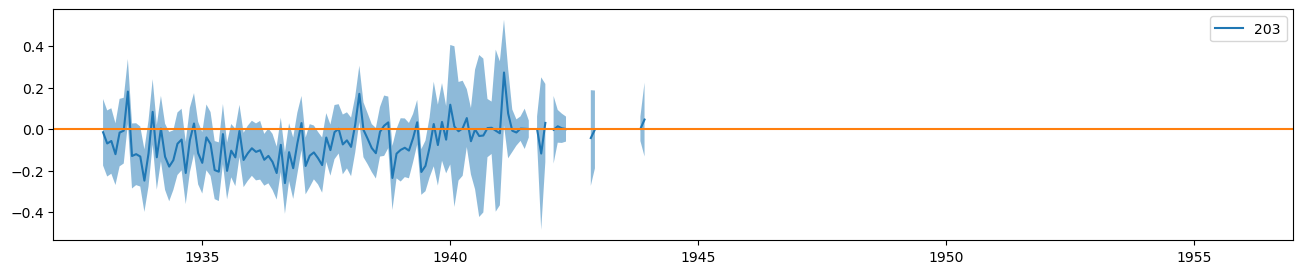

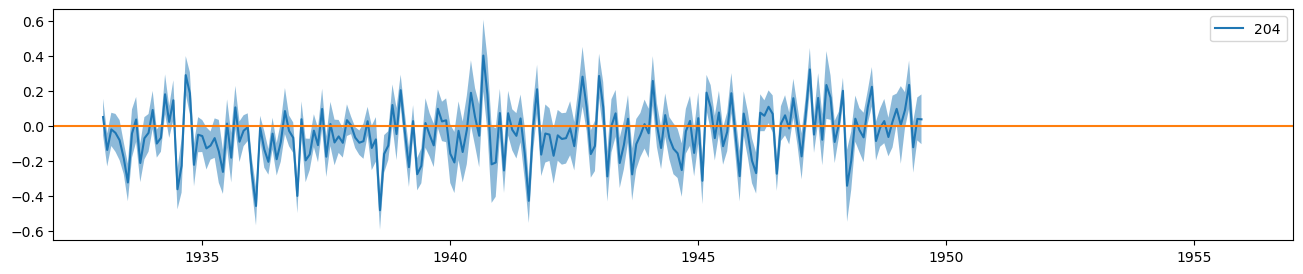

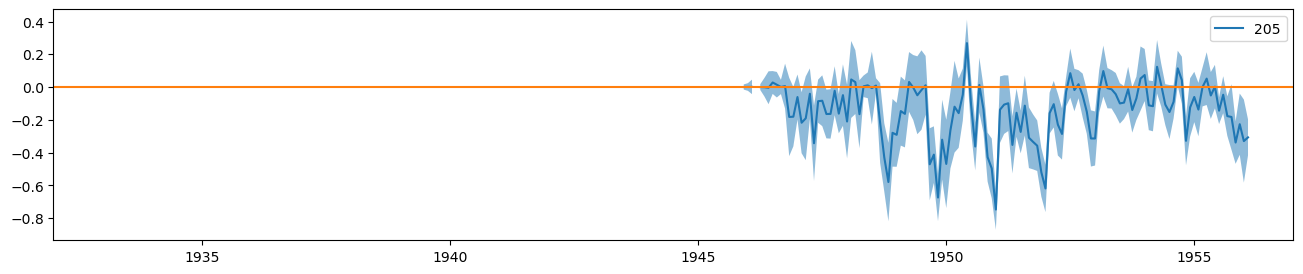

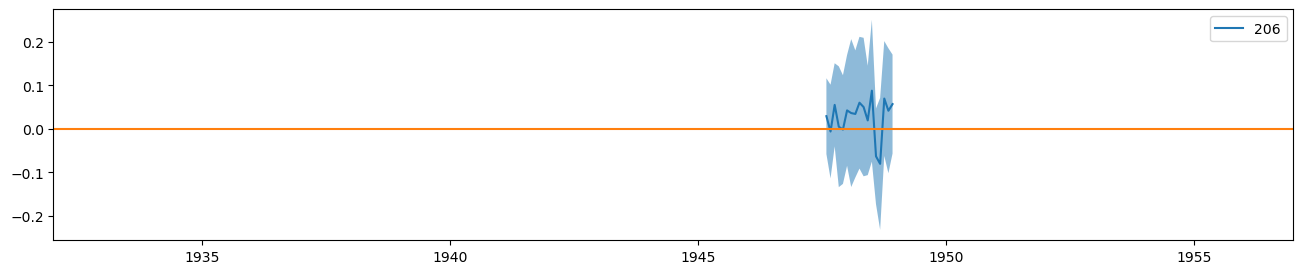

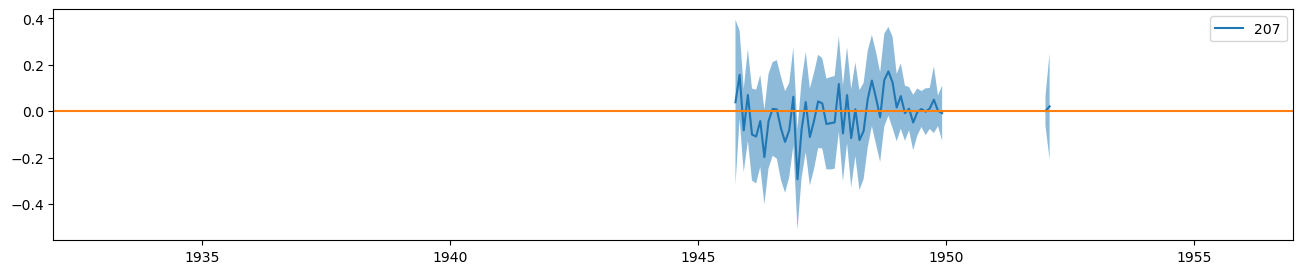

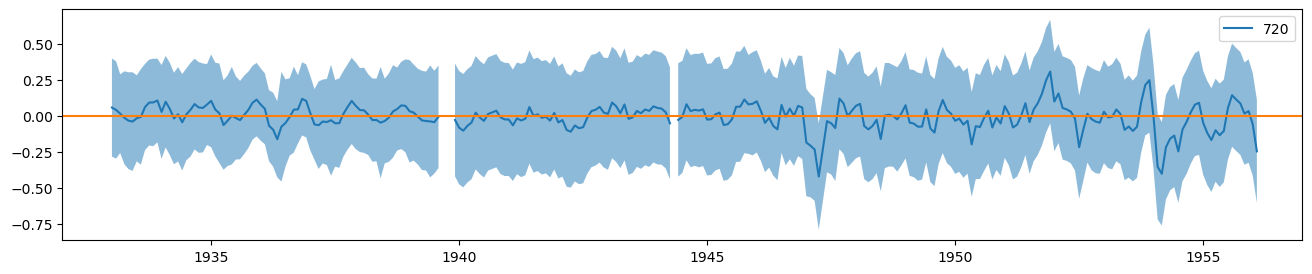

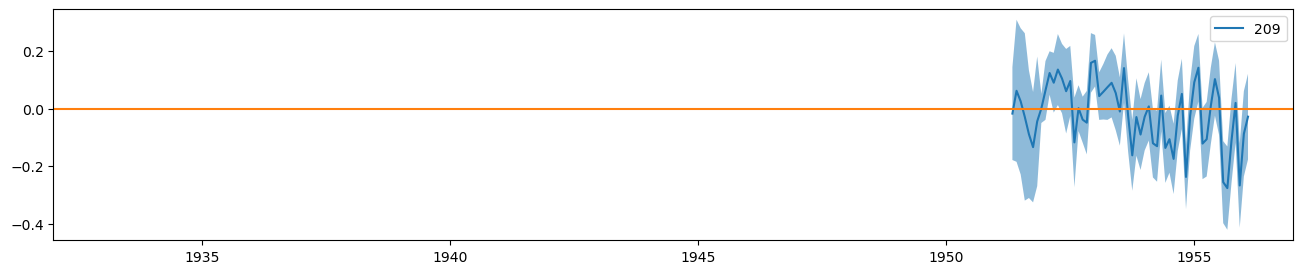

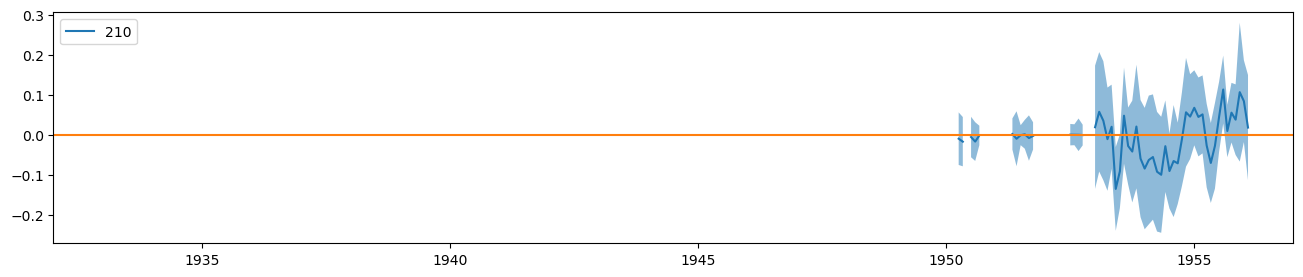

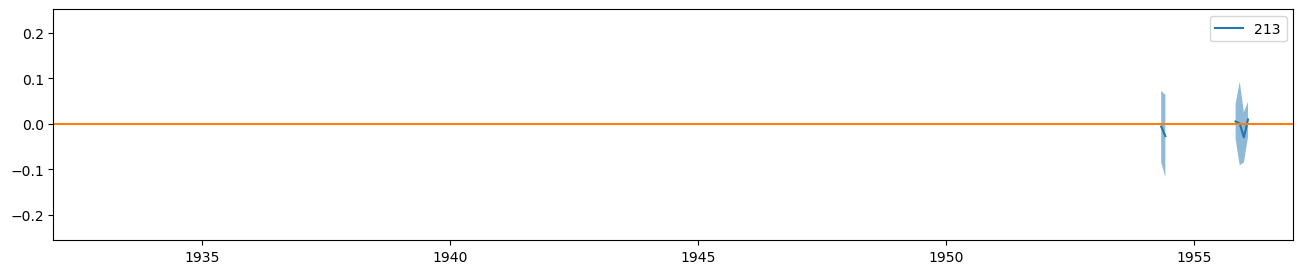

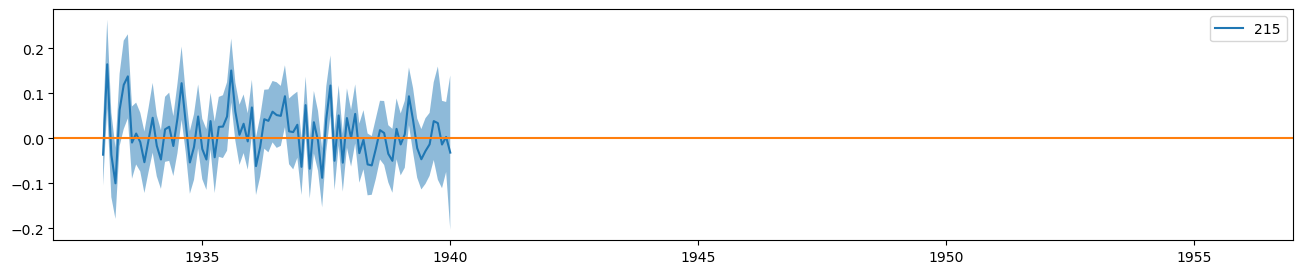

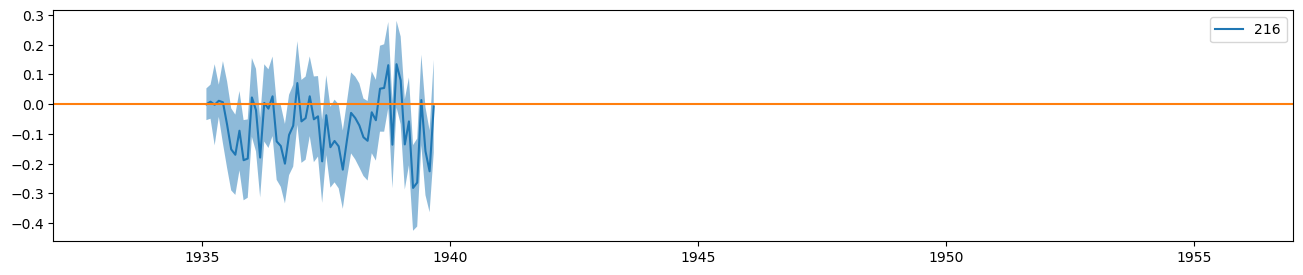

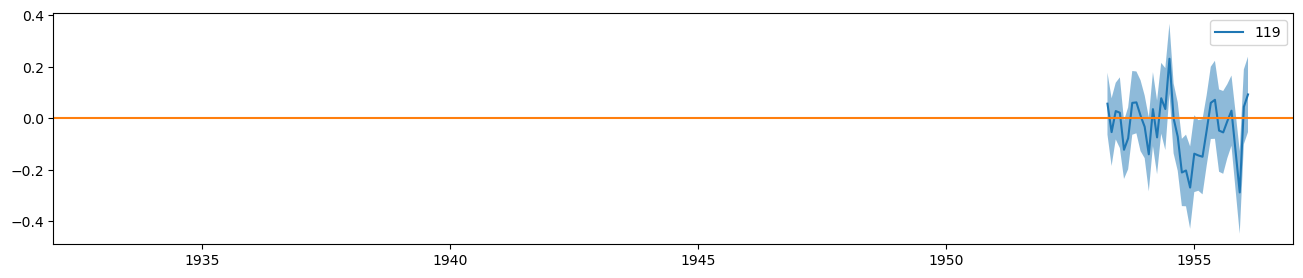

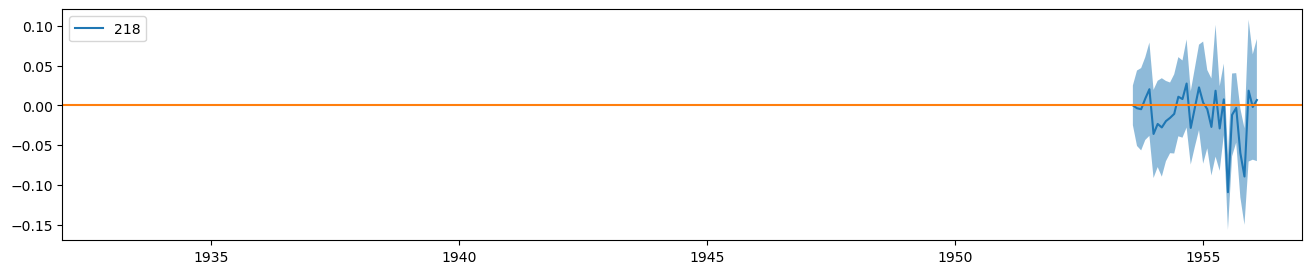

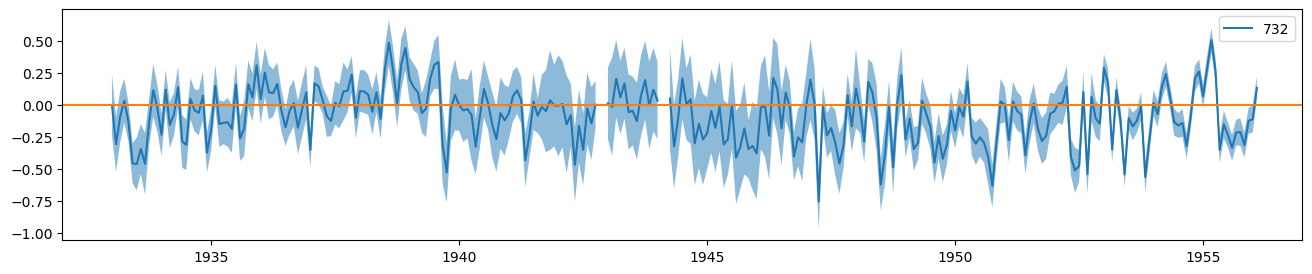

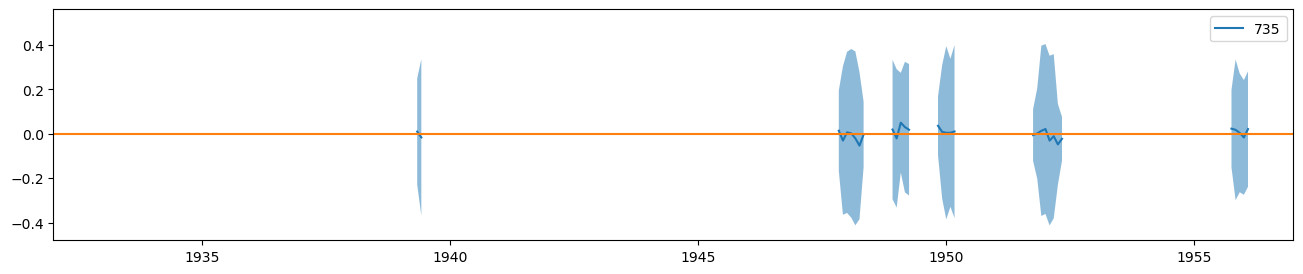

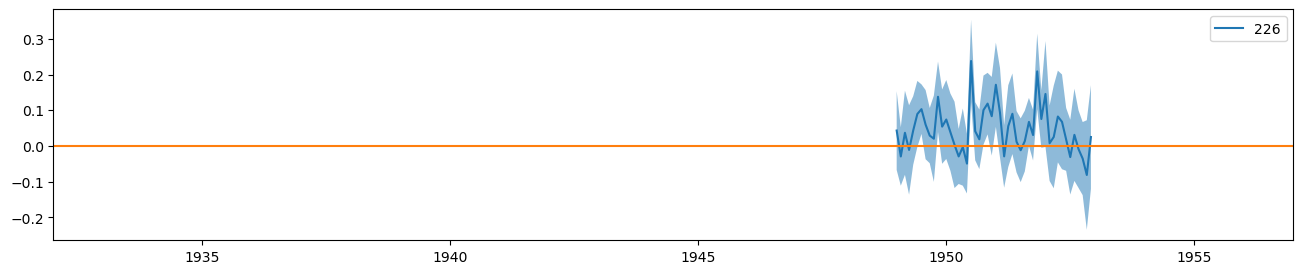

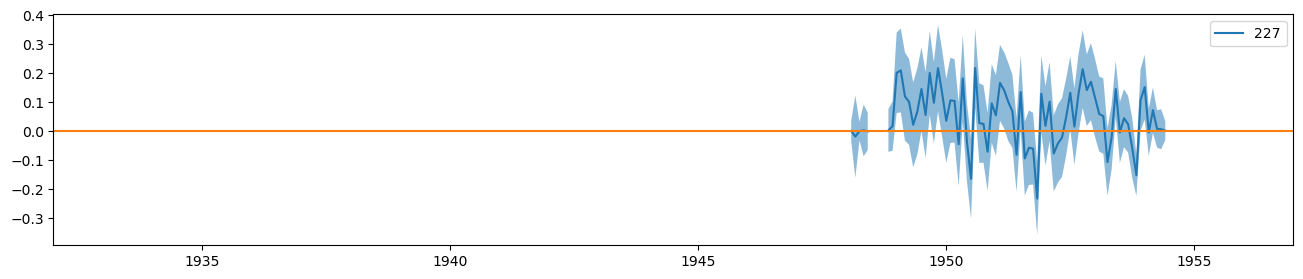

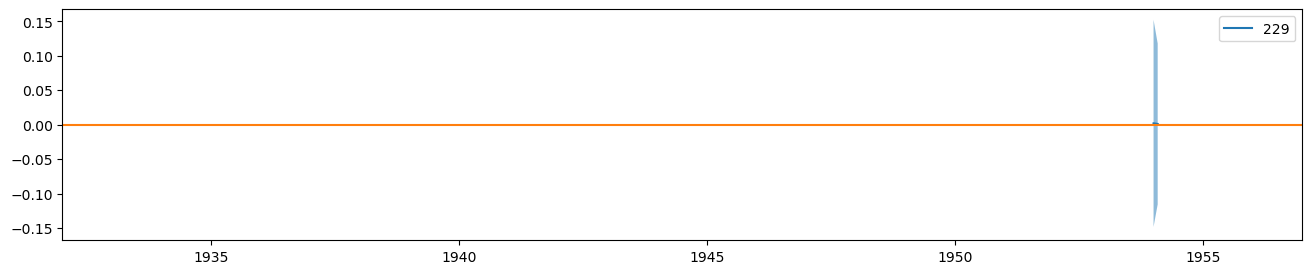

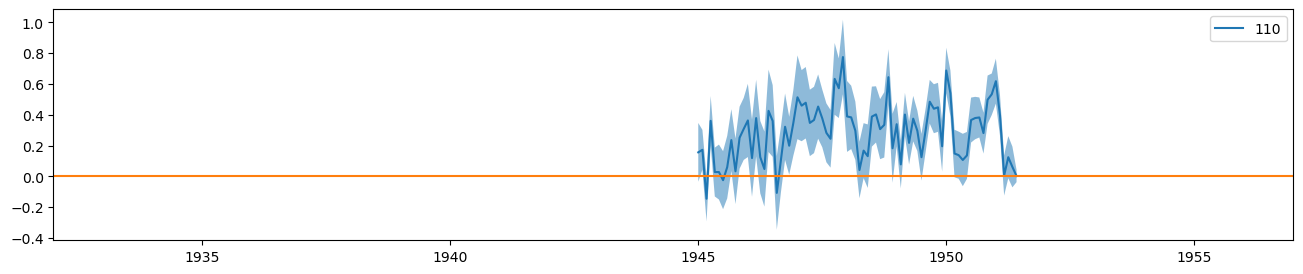

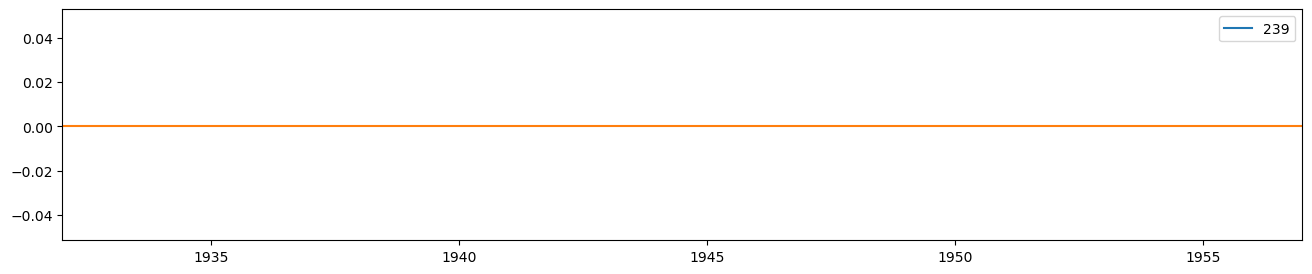

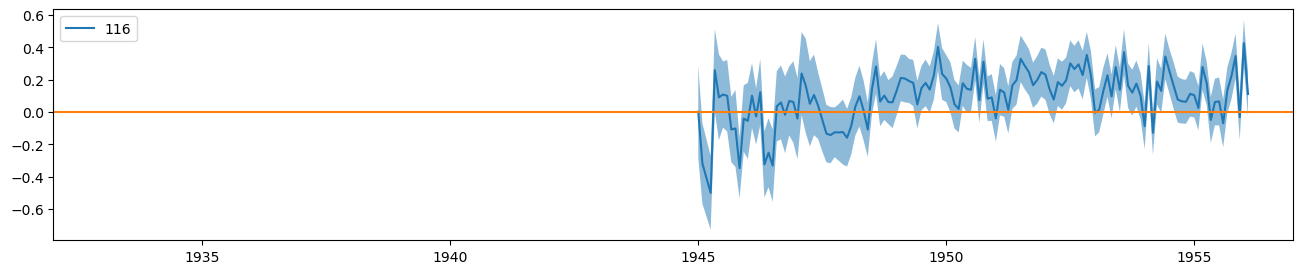

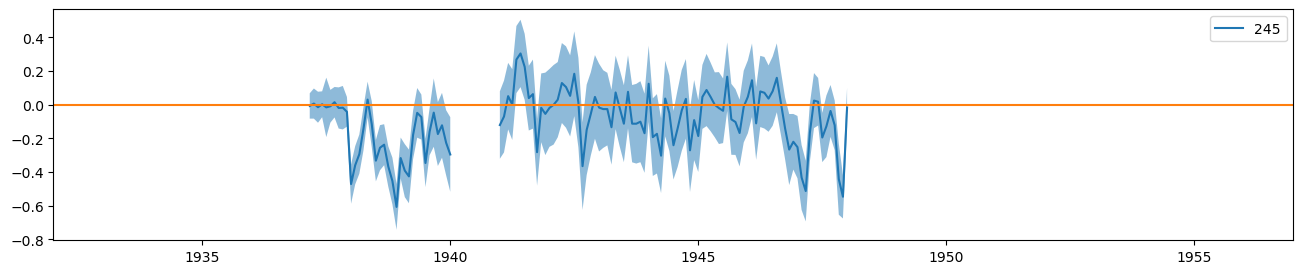

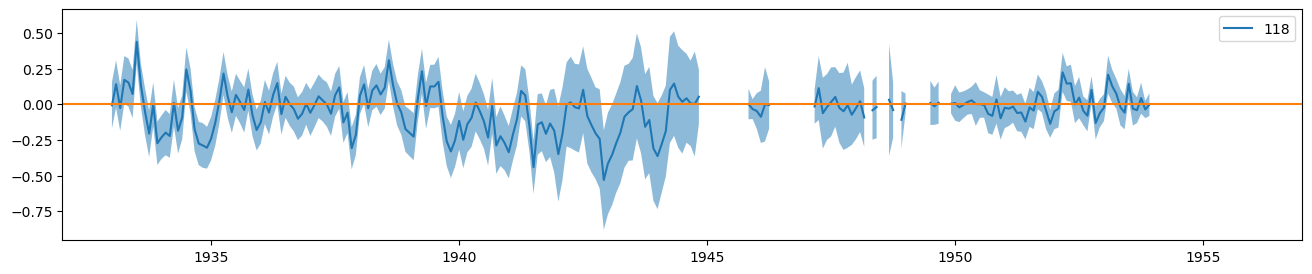

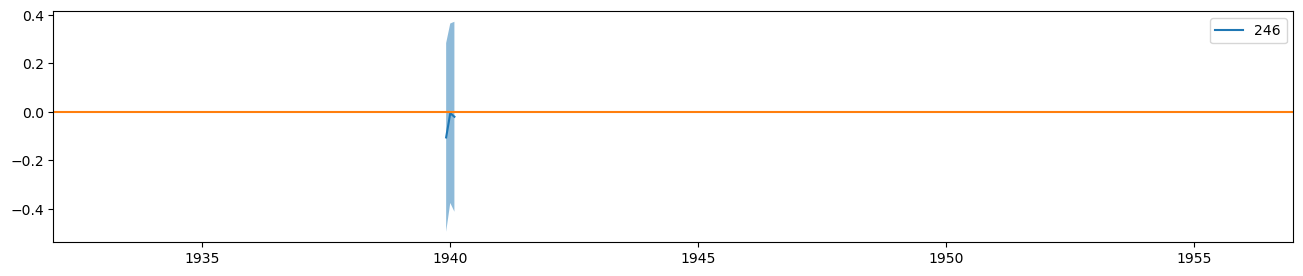

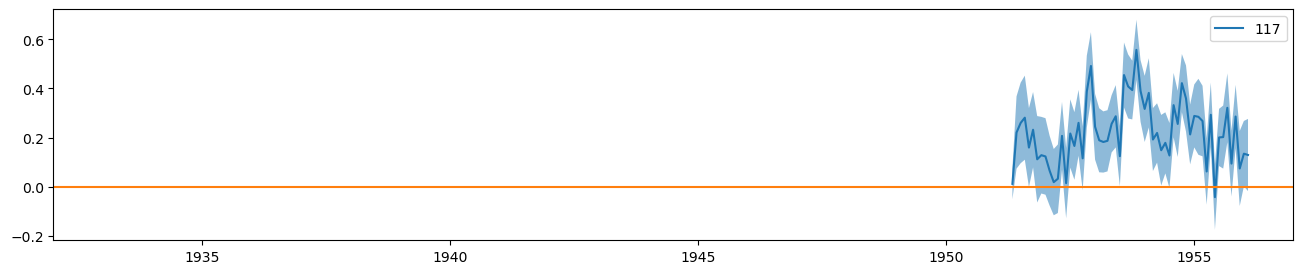

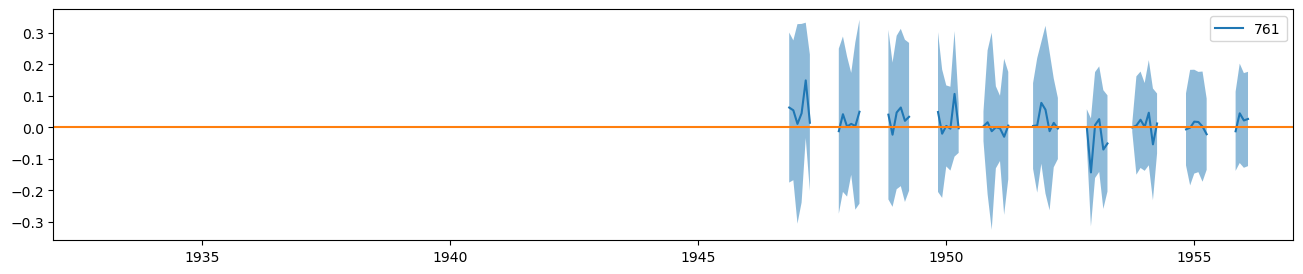

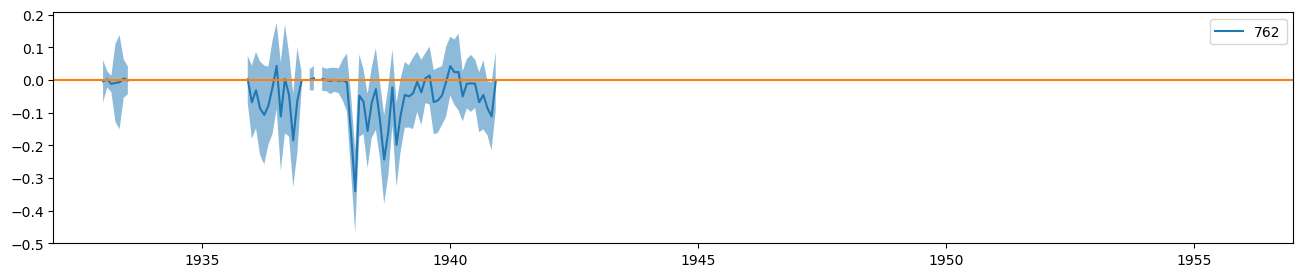

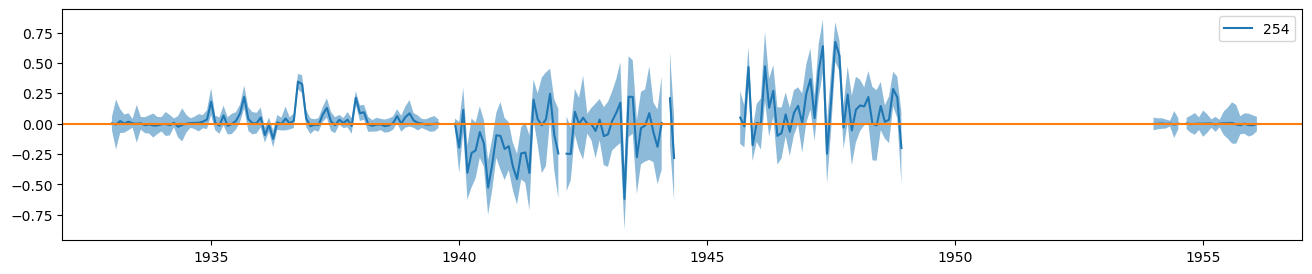

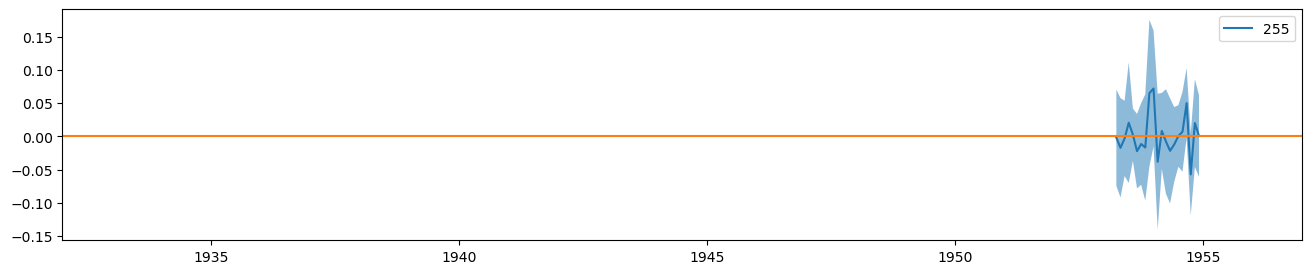

In [4]:
time = np.arange(n_time)/12. + 1850.
unique_decks = set(deck_list)


count = 0
for dck in unique_decks:
    plt.figure()
    plt.gcf().set_size_inches(16, 3)
    plt.fill_between(time, all_decks[:, dck]-2*all_decks_unc[:, dck], all_decks[:, dck]+2*all_decks_unc[:, dck], alpha=0.5)
    plt.plot(time, all_decks[:, dck], label=dck)
    plt.plot([1850,2025],[0., 0.])
    plt.legend()
    plt.xlim(1932, last_year+1)
    plt.show()
    count += 1
